## Inspect Partition
Evaluate Wang and Jordan partitions

In [12]:
%matplotlib ipympl
import matplotlib.pyplot as plt
import numpy as np

from buildforcing.metfuncs import (
    calculate_wetbulb, rh_to_q, e_from_wetbulb, esat_ice, esat_liq,
    wang2019_snowfrac, jordan_snowfrac
)

#### Verify Wang curve

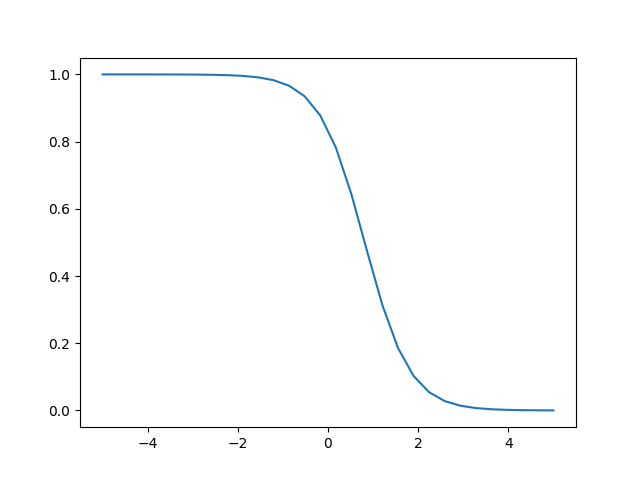

In [7]:
# Setup parameters
Twb_range = np.linspace(-5, 5, 30)  # Temperature in C
snow_fracs = wang2019_snowfrac(Twb_range)

plt.figure()
plt.plot(Twb_range,snow_fracs)
plt.show()

#### Check wetbulb

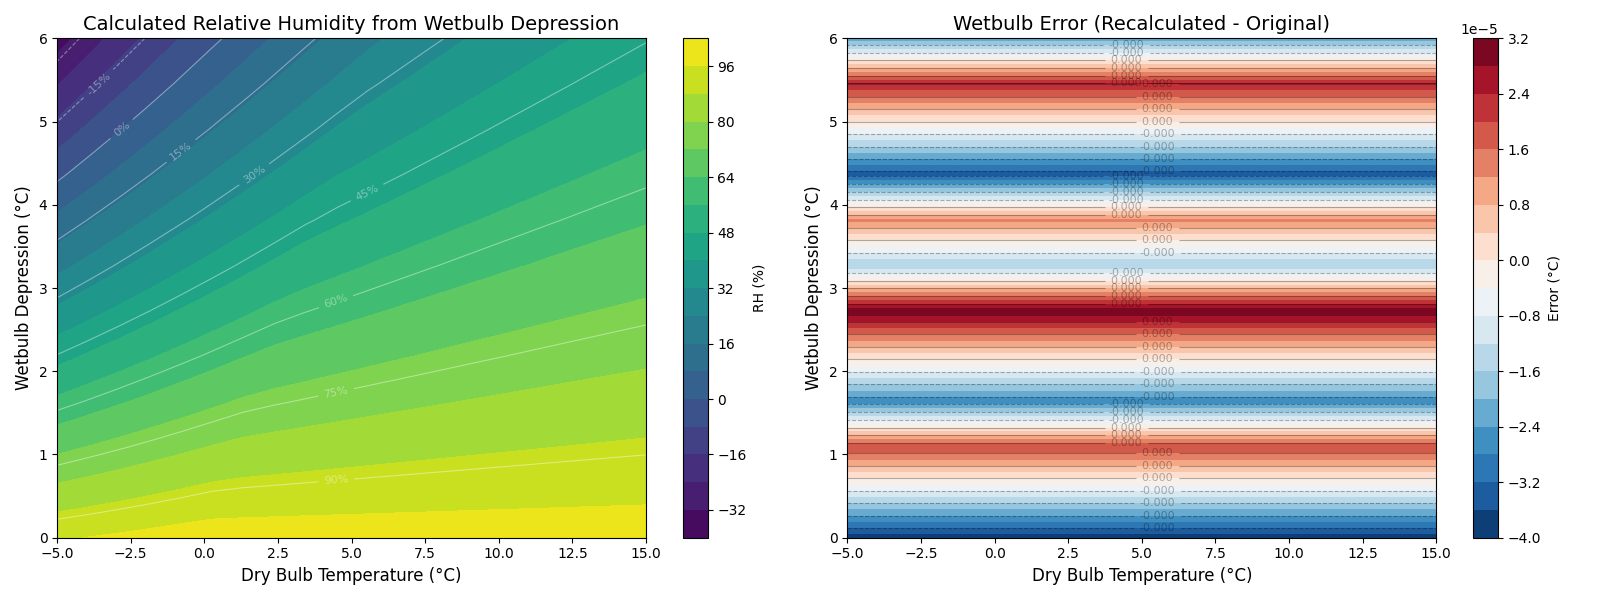

RH range: -35.7% to 100.0%

Wetbulb Temperature Error:
  Max absolute error: 0.000038 °C
  Mean absolute error: 0.000020 °C


In [19]:
# Verify that wetbulb calculates the correct humidity
# First step: Plot the calculated RH values
# Second step: Recalculate wetbulb and plot the error

temp_range = np.linspace(-5, 15, 20)  # Dry bulb temperatures (C)
wetbulb_depressions = np.linspace(0, 6, 12)  # T - Twb (C)
pressure_value = 100000  # Pa

# Create a grid to store results
T_grid, D_grid = np.meshgrid(temp_range, wetbulb_depressions)
Twb_original = T_grid - D_grid  # Original wetbulb temperature

# Step 1: Calculate vapor pressure from the original wetbulb
e_vals = e_from_wetbulb(T_grid.flatten(), Twb_original.flatten(), 
                        np.full_like(T_grid.flatten(), pressure_value))

# Step 2: Convert vapor pressure to RH using saturation vapor pressure
# Calculate saturation vapor pressure at dry bulb temperature
e_sat = esat_liq(T_grid.flatten())  # Saturation vapor pressure at T

# Calculate RH as ratio of actual to saturation vapor pressure
rh_calculated = (e_vals / e_sat) * 100.0

# Step 3: Convert RH back to specific humidity
# FIXED: Convert RH from percentage to fraction (0-1) as expected by rh_to_q
q_from_rh = rh_to_q(rh_calculated / 100.0, T_grid.flatten(),
                    np.full_like(T_grid.flatten(), pressure_value))

# Step 4: Recalculate wetbulb from the humidity
Twb_recalculated = calculate_wetbulb(T_grid.flatten(), q_from_rh, 
                                      np.full_like(T_grid.flatten(), pressure_value))

# Reshape back to grid
rh_calculated = rh_calculated.reshape(T_grid.shape)
Twb_recalculated = Twb_recalculated.reshape(T_grid.shape)

# Calculate the error
error_twb = Twb_recalculated - Twb_original

# Create two plots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Calculated RH
im1 = ax1.contourf(T_grid, D_grid, rh_calculated, levels=20, cmap='viridis')
contours1 = ax1.contour(T_grid, D_grid, rh_calculated, levels=10, colors='white', alpha=0.4, linewidths=0.8)
ax1.clabel(contours1, inline=True, fontsize=8, fmt='%0.0f%%')
ax1.set_xlabel('Dry Bulb Temperature (°C)', fontsize=12)
ax1.set_ylabel('Wetbulb Depression (°C)', fontsize=12)
ax1.set_title('Calculated Relative Humidity from Wetbulb Depression', fontsize=14)
plt.colorbar(im1, ax=ax1, label='RH (%)')

# Plot 2: Wetbulb error
im2 = ax2.contourf(T_grid, D_grid, error_twb, levels=20, cmap='RdBu_r')
contours2 = ax2.contour(T_grid, D_grid, error_twb, levels=10, colors='black', alpha=0.3, linewidths=0.8)
ax2.clabel(contours2, inline=True, fontsize=8, fmt='%0.3f')
ax2.set_xlabel('Dry Bulb Temperature (°C)', fontsize=12)
ax2.set_ylabel('Wetbulb Depression (°C)', fontsize=12)
ax2.set_title('Wetbulb Error (Recalculated - Original)', fontsize=14)
plt.colorbar(im2, ax=ax2, label='Error (°C)')

plt.tight_layout()
plt.show()

print(f"RH range: {rh_calculated.min():.1f}% to {rh_calculated.max():.1f}%")
print(f"\nWetbulb Temperature Error:")
print(f"  Max absolute error: {np.abs(error_twb).max():.6f} °C")
print(f"  Mean absolute error: {np.abs(error_twb).mean():.6f} °C")

### Verify with humidity

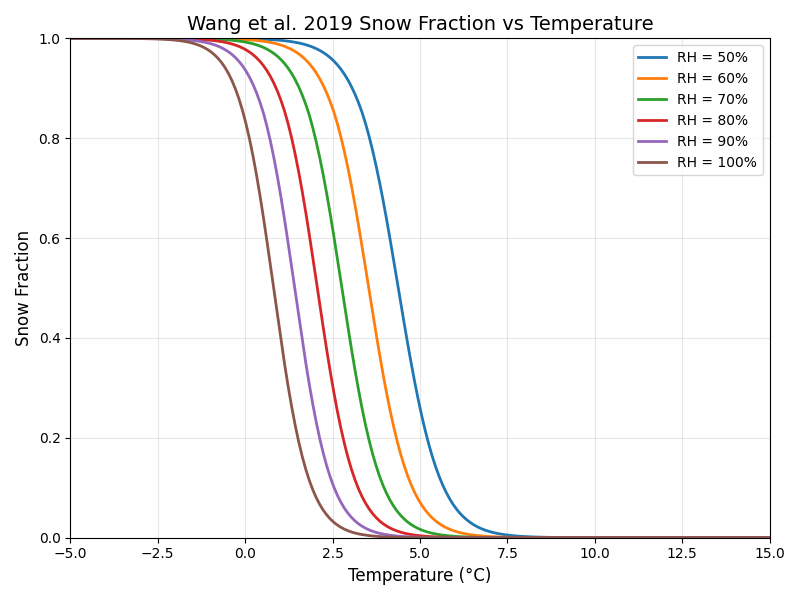

In [24]:


# Setup parameters
temp_range = np.linspace(-5, 15, 200)  # Temperature in C
rh_values = np.arange(50, 101, 10)  # Relative humidity from 50% to 100%
pressure_value = 100000  # Pa (constant)

# Create figure
fig, ax = plt.subplots(figsize=(8, 6))

# Plot snow fraction for each RH value
for rh in rh_values:
    # Create arrays with same length as temp_range
    temp_array = temp_range
    rh_array = np.full_like(temp_array, rh)
    pressure_array = np.full_like(temp_array, pressure_value)
    
    # Calculate wet bulb temperature
    q = rh_to_q(rh_array/100, temp_array, pressure_array)
    twet = calculate_wetbulb(temp_array, q, pressure_array)
    
    # Calculate snow fraction using wet bulb temperature
    snow_fracs = wang2019_snowfrac(twet)
    
    ax.plot(temp_array, snow_fracs, label=f'RH = {rh}%', linewidth=2)

# Format plot
ax.set_xlabel('Temperature (°C)', fontsize=12)
ax.set_ylabel('Snow Fraction', fontsize=12)
ax.set_title('Wang et al. 2019 Snow Fraction vs Temperature', fontsize=14)
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 15)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()